In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

sns.set_palette("colorblind")

CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM
N_TAIL_EVALS = 3  # matches compute_final_values' n_tail elsewhere in this repo

CSV_PATHS = {
    "lightsout": "lightsout-icot-final.csv",
    "slidingpuzzle": "slidingpuzzle-icot-final.csv",
    "sokoban": "sokoban-icot-final.csv",
}

FILTERS = {
    "lightsout": {
        "system.gamma": 0.999,
    },
    "slidingpuzzle": {
        "network.actor_network.pre_torso.halting_temperature": 1.0,
        "network.actor_network.pre_torso.stop_gradient_halting_input": False,
        "system.actor_lr": 0.0003,
        "system.halting_ent_coef": 0.0,
        "system.clip_halting_head": True,
    },
    "sokoban": {
        "network.actor_network.pre_torso.halting_temperature": 1.0,
        "network.actor_network.pre_torso.stop_gradient_halting_input": False,
        "system.halting_ent_coef": 0.01,
        "system.clip_halting_head": False,
    },
}


ARCH = None  # None = use whichever single arch is present in the CSV
TRIM_N = 0  # drop this many highest- and lowest-performing seeds per (budget, gamma) group before averaging


In [2]:
def get_df(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df["state"] == "finished"]
    df = df[~df["sgh"]]

    missing = [c for c in ("gamma", "absolute/episode_return/mean") if c not in df.columns]
    if missing:
        raise ValueError(
            f"{csv_path} is missing {missing} - re-fetch it with the updated fetch_wandb_lightsout_hd64.py"
        )
    df = df[df["gamma"].notna()]

    if ARCH is None:
        archs = df["arch"].unique()
        if len(archs) != 1:
            raise ValueError(f"Multiple architectures present ({list(archs)}) - set ARCH explicitly")
        ARCH = archs[0]
    df = df[df["arch"] == ARCH]

    return df

In [3]:
def budget_label(min_steps, max_steps):
    return f"uniform={min_steps}" if min_steps == max_steps else f"adaptive[{min_steps}-{max_steps}]"


[lightsout] 60 runs kept: {(1, 1): 10, (1, 5): 10, (2, 2): 10, (3, 3): 10, (4, 4): 10, (5, 5): 10}
[slidingpuzzle] 60 runs kept: {(1, 1): 10, (1, 5): 10, (2, 2): 10, (3, 3): 10, (4, 4): 10, (5, 5): 10}
[sokoban] 30 runs kept: {(1, 1): 5, (1, 5): 5, (2, 2): 5, (3, 3): 5, (4, 4): 5, (5, 5): 5}


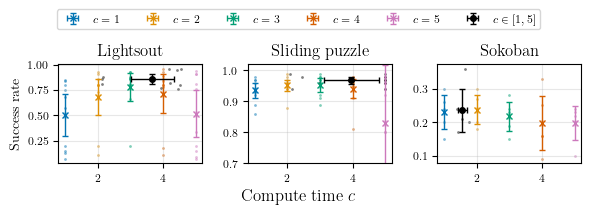

In [6]:
# Compute vs. solve rate: one point per budget (mean +- 95% CI over seeds, in both axes).
# The absolute/* metrics are a single post-training value per run, so each run contributes one (x, y).
X_METRIC = "absolute/compute_time/mean"
# lightsout/slidingpuzzle reward 1 on solve and 0 otherwise, so their return is already the solve rate;
# sokoban's return includes per-step penalties, so it needs the logged solved_episode.
Y_METRICS = {
    "lightsout": "absolute/episode_return/mean",
    "slidingpuzzle": "absolute/episode_return/mean",
    "sokoban": "absolute/solved_episode/mean",
}

# FILTERS keys are wandb config paths; the CSVs store a subset under short names.
FILTER_KEY_TO_COLUMN = {
    "system.gamma": "gamma",
    "system.ent_coef": "ent_coef",
    "network.actor_network.pre_torso.halting_temperature": "halting_temperature",
    "network.actor_network.pre_torso.stop_gradient_halting_input": "sgh",
    "system.halting_ent_coef": "halting_ent_coef",
    "system.actor_lr": "actor_lr",
    "system.clip_halting_head": "clip_halting_head",
}
# Only meaningful for adaptive (min_steps < max_steps) policies.
HALTING_FILTER_KEYS = {
    "network.actor_network.pre_torso.halting_temperature",
    "network.actor_network.pre_torso.stop_gradient_halting_input",
    "system.halting_ent_coef",
    "system.clip_halting_head",
}

ENV_NAMES = {
    "lightsout": "Lightsout",
    "slidingpuzzle": "Sliding puzzle",
    "sokoban": "Sokoban",
}


def load_filtered(env_name):
    df = pd.read_csv(CSV_PATHS[env_name])
    df = df[df["state"] == "finished"]
    adaptive = df["min_steps"] != df["max_steps"]
    keep = pd.Series(True, index=df.index)
    for key, val in FILTERS.get(env_name, {}).items():
        col = FILTER_KEY_TO_COLUMN.get(key)
        if col is None or col not in df.columns:
            print(f"[{env_name}] filter {key!r} has no CSV column - ignored")
            continue
        match = np.isclose(df[col], val) if isinstance(val, float) else (df[col] == val)
        keep &= (match | ~adaptive) if key in HALTING_FILTER_KEYS else match
    df = df[keep]
    runs = df.drop_duplicates("run_id")
    print(
        f"[{env_name}] {runs['run_id'].nunique()} runs kept:",
        runs.groupby(["min_steps", "max_steps"]).size().to_dict(),
    )
    return df


def compute_vs_solve(df, y_metric):
    per_run = df.groupby("run_id").agg(
        x=(X_METRIC, "first"), y=(y_metric, "first"),
        min_steps=("min_steps", "first"), max_steps=("max_steps", "first"),
    ).dropna(subset=["x", "y"])
    rows = []
    for (mn, mx), g in per_run.groupby(["min_steps", "max_steps"]):
        n = len(g)
        sem = lambda s: CI95_Z * s.std() / np.sqrt(n) if n > 1 else 0.0
        rows.append({
            "budget": budget_label(mn, mx), "n": n,
            "x": g["x"].mean(), "x_ci": sem(g["x"]),
            "y": g["y"].mean(), "y_ci": sem(g["y"]),
            "xs": g["x"].values, "ys": g["y"].values,
        })
    return pd.DataFrame(rows)


def pretty_budget(budget):
    if "uniform" in budget:
        return "$c = {}$".format(budget.split("=")[-1])
    lo, hi = budget.split("[")[1].rstrip("]").split("-")
    return "$c \\in [{}, {}]$".format(lo, hi)


env_names = list(CSV_PATHS)
nrows, ncols = 1, len(env_names)
figsize = set_size(doc_width_pt, fraction=0.95, subplots=(nrows, ncols), use_golden_ratio=False)
fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=False)

# One palette across panels so a budget keeps its colour even when a panel is missing it.
colors = dict(zip([budget_label(c, c) for c in range(1, 6)], sns.color_palette("colorblind")))
legend_entries = {}
for ax, env_name in zip(np.atleast_1d(axes), env_names):
    df_env = load_filtered(env_name)
    y_metric = Y_METRICS[env_name]
    if y_metric not in df_env.columns:
        raise ValueError(f"{CSV_PATHS[env_name]} is missing {y_metric!r} - re-fetch it with fetch_wandb.py")
    stats = compute_vs_solve(df_env, y_metric)
    budgets = sorted(stats["budget"], key=lambda b: (b.startswith("adaptive"), b))
    for _, row in stats.set_index("budget").loc[budgets].reset_index().iterrows():
        color = colors.get(row["budget"], (0.0, 0.0, 0.0))
        ax.scatter(row["xs"], row["ys"], color=color, s=4, alpha=0.5, linewidths=0)
        h = ax.errorbar(
            row["x"], row["y"], xerr=row["x_ci"], yerr=row["y_ci"],
            fmt="o" if row["budget"].startswith("adaptive") else "x",
            color=color, ms=4, elinewidth=1, capsize=2,
        )
        legend_entries.setdefault(pretty_budget(row["budget"]), h)
    ax.set_title(ENV_NAMES[env_name])
    ax.grid(True, alpha=0.3)
    if env_name == "slidingpuzzle":
        ax.set_ylim(0.7, 1.02)

np.atleast_1d(axes)[0].set_ylabel("Success rate")
fig.supxlabel("Compute time $c$", y=0.12)
fig.legend(
    legend_entries.values(), legend_entries.keys(),
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0), loc="lower center",
    ncols=6, borderaxespad=0.0, frameon=True,
)
fig.tight_layout()
plt.savefig("analysis-icot-compute-vs-solve.pdf", dpi=600, format="pdf", bbox_inches="tight")
